# Random FDLU noising single layer

Created: 23-06-2026

Objectives:
* Build off [previous notebook](random_fdlu_noising.ipynb), but now just apply a single layer FDLU.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

In [6]:
from scipy.stats import ortho_group

In [7]:
from collections import Counter

In [8]:
import pandas as pd

# Definitions
## Groundstates

In [9]:
num_sites = 16

In [10]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [11]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=num_sites):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [12]:
parameters = np.linspace(0, 1, 11)

In [13]:
hamiltonians = [
    get_hamiltoniain(t, num_sites)
    for t in parameters
]

In [14]:
energies = list()
groundstates = list()

for h in tqdm(hamiltonians):
    e, psi = h.eigsh(k=1, which='SA')

    energies.append(e)
    groundstates.append(psi)

100%|███████████████████████████████████████████████████████████████████████████████| 11/11 [00:07<00:00,  1.56it/s]


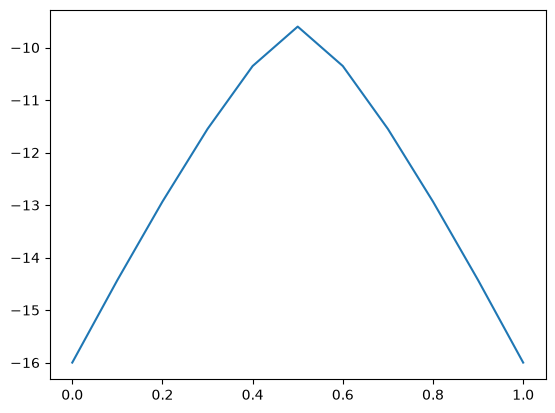

In [15]:
plt.plot(parameters, energies)

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [16]:
np_X = np.array([
    [0,1],
    [1,0]
])

np_XX = np.kron(np_X, np_X)

In [17]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

## Defect operators

In [18]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [19]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [20]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [21]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [22]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [23]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [24]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [25]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [26]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [27]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [28]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [29]:
def get_tensor_network_factorization(qt_rho, rho_purity):
    A_left = qtn.Tensor(
        data=random_uniform_complex(
            (vertical_bond_dimension, 2**4, horiztonal_bond_dimension)
        ),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex(
            (horiztonal_bond_dimension, 2**4, vertical_bond_dimension)
        ),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    return A_opt, tnopt.losses, tnopt.loss_best

In [30]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [31]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (4, 4),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [32]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={'kl': (4, 4), 'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={'bl': (4, 4), 'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [33]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={'kl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={'bl': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (4, 4)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (4, 4)}
        )
    )

    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={'kl': (4, 4), 'bl': (4,4)}
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={'kr': (4, 4), 'br': (4,4)}
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [34]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlap
    )

    return out

In [35]:
def get_defect_ops_and_indices_from_restricted_purification_state(psi_restricted):
    psi_0 = psi_restricted

    # Effective density matrix
    edm = (
        psi_0
        & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
        & qu_XX.reindex({'k': 'kl2', 'b': 'bl2'})
        & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
        & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )

    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & qu_XX.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [36]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={'kl': (4, 4)}
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={'kr': (4, 4)}
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [37]:
def get_restricted_psis_from_purification(qt_rho, cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data
    
    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={'kl': (4, 4), 'kr': (4, 4)}
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [38]:
def get_left_right_defect_regions_schmidt_vals(qt_rho):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }
    shape_map = {k: (4,4) for k in unfuse_map.keys()}

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [39]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    rho.contract(inplace=True)

    return rho

In [40]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

In [41]:
def extract_time_reversal_information(psi):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, symmetry_sites)
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': ['k4', 'k5', 'k6', 'k7'],
            'kr': ['k8', 'k9', 'k10', 'k11'],
            'bl': ['b4', 'b5', 'b6', 'b7'],
            'br': ['b8', 'b9', 'b10', 'b11']
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho)

    pair = get_restricted_psis_from_purification(qt_rho)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [sv, *get_defect_ops_and_indices_from_restricted_purification_state(psi_0)]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(qt_rho, rho_purity)

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [sl, sr, *get_defect_ops_and_indices_from_restricted_state(psi_0)]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

## Apply random unitary to groundstate

In [42]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [43]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quspin_state(psi):
    qu_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    for i in range(num_sites//2):
        site_1 = ((2*i))%num_sites
        site_2 = ((2*i)+1)%num_sites

        u = generate_random_symmetry_respecting_unitary()
        
        qu_u = qtn.Tensor(
            u.reshape((2,)*4),
            inds=[f'k{site_1}', f'k{site_2}', f'b{site_1}', f'b{site_2}']
        )

        qu_psi = (
            qu_psi.reindex(
                {f'k{site_1}':  f'b{site_1}', f'k{site_2}': f'b{site_2}'}
            )
            & qu_u
        )
        qu_psi.contract(inplace=True)

    out_psi = qu_psi.tensors[0].data.reshape((-1))[::-1]

    return out_psi

In [49]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi):
    out_psi = psi.copy()

    for i in range(num_sites//2):
        site_1 = ((2*i))%num_sites
        site_2 = ((2*i)+1)%num_sites

        u = generate_random_symmetry_respecting_unitary()
        
        qu_u = qtn.Tensor(
            u.reshape((2,)*4),
            inds=[f'k{site_1}', f'k{site_2}', f'b{site_1}', f'b{site_2}']
        )

        out_psi = (
            out_psi.reindex(
                {f'k{site_1}':  f'b{site_1}', f'k{site_2}': f'b{site_2}'}
            )
            & qu_u
        )
        out_psi.contract(inplace=True)

    return out_psi

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [45]:
def extract_time_reversal_information_after_random_fdlu(psi, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi)
        out.append(extract_time_reversal_information(rand_psi))

    return out

In [46]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

# Sweep

In [50]:
fixed_point_groundstates = [
    groundstates[0],
    groundstates[-1],
]

In [52]:
quimb_fixed_point_groundstates = [
    get_quimb_psi_from_quspin_psi(psi)
    for psi in fixed_point_groundstates
]

In [53]:
sweep_results = list()

for psi in tqdm(quimb_fixed_point_groundstates):
    l = extract_time_reversal_information_after_random_fdlu(psi, 20)
    sweep_results.append(l)

  0%|                                                                                         | 0/2 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████| 2/2 [00:47<00:00, 23.65s/it]


## Analyse results

### Left right rho schmidt values

#### Trivial

In [72]:
triv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in sweep_results[0]
]

In [73]:
num_triv_schmidt_vals = [len(l) for l in triv_schmidt_vals]

In [74]:
Counter(num_triv_schmidt_vals)

Counter({1: 20})

In [75]:
triv_schmidt_vals

[[np.float64(1.0000000000000082)],
 [np.float64(1.0000000000000084)],
 [np.float64(1.0000000000000075)],
 [np.float64(1.0000000000000067)],
 [np.float64(1.0000000000000073)],
 [np.float64(1.0000000000000078)],
 [np.float64(1.0000000000000089)],
 [np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000075)],
 [np.float64(1.0000000000000069)],
 [np.float64(1.000000000000007)],
 [np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000073)],
 [np.float64(1.0000000000000073)],
 [np.float64(1.0000000000000078)],
 [np.float64(1.000000000000007)],
 [np.float64(1.0000000000000069)],
 [np.float64(1.000000000000007)],
 [np.float64(1.000000000000006)],
 [np.float64(1.000000000000007)]]

In [76]:
def get_schmidt_vals_ratio(l):
    if len(l) == 1:
        return 0
    else:
        return l[1]/l[0]

In [77]:
triv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in triv_schmidt_vals
]

In [78]:
pd.Series(triv_schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

#### Non-trivial

In [79]:
nontriv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in sweep_results[1]
]

In [80]:
num_nontriv_schmidt_vals = [len(l) for l in nontriv_schmidt_vals]

In [81]:
Counter(num_nontriv_schmidt_vals)

Counter({1: 20})

In [82]:
nontriv_schmidt_vals

[[np.float64(0.2500000000000016)],
 [np.float64(0.2500000000000018)],
 [np.float64(0.2500000000000018)],
 [np.float64(0.2500000000000017)],
 [np.float64(0.2500000000000017)],
 [np.float64(0.2500000000000017)],
 [np.float64(0.2500000000000015)],
 [np.float64(0.25000000000000194)],
 [np.float64(0.250000000000002)],
 [np.float64(0.2500000000000019)],
 [np.float64(0.2500000000000017)],
 [np.float64(0.2500000000000017)],
 [np.float64(0.2500000000000018)],
 [np.float64(0.2500000000000015)],
 [np.float64(0.2500000000000018)],
 [np.float64(0.25000000000000167)],
 [np.float64(0.25000000000000167)],
 [np.float64(0.25000000000000183)],
 [np.float64(0.2500000000000016)],
 [np.float64(0.2500000000000017)]]

In [83]:
nontriv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in nontriv_schmidt_vals
]

In [84]:
pd.Series(nontriv_schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

Hmm...

### Purification full effective density matrix
Output data:
* left_right_singular_vals
* left_defect_op_invariant
* right_defect_op_invariant
* overlaps
* purification_diff_score

#### Trivial

In [85]:
purification_rho_sweep_results = [l[1] for l in sweep_results[0]]

In [86]:
purification_rho_sweep_results[0][0]

array([1.])

In [87]:
purification_rho_sweep_results[-1][0]

array([1.])

In [88]:
triv_schmidt_vals = [
    [x for x in l[0] if x > 0.05]
    for l in purification_rho_sweep_results
]

In [89]:
num_triv_schmidt_vals = [len(l) for l in triv_schmidt_vals]

In [90]:
Counter(num_triv_schmidt_vals)

Counter({1: 20})

In [91]:
triv_schmidt_vals

[[np.float64(1.0000000000000084)],
 [np.float64(1.0000000000000073)],
 [np.float64(1.000000000000008)],
 [np.float64(1.0000000000000069)],
 [np.float64(1.0000000000000067)],
 [np.float64(1.0000000000000084)],
 [np.float64(1.0000000000000089)],
 [np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000084)],
 [np.float64(1.0000000000000064)],
 [np.float64(1.0000000000000073)],
 [np.float64(1.0000000000000067)],
 [np.float64(1.0000000000000049)],
 [np.float64(1.0000000000000067)],
 [np.float64(1.000000000000008)],
 [np.float64(1.000000000000006)],
 [np.float64(1.0000000000000073)],
 [np.float64(1.0000000000000073)],
 [np.float64(1.000000000000006)],
 [np.float64(1.000000000000007)]]

In [92]:
triv_schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in triv_schmidt_vals
]

In [93]:
pd.Series(triv_schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

This is exactly the same as the corresponding results for $rho$ in the previous section! Is this expected?

In [94]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [95]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(1.1102230246251565e-16), np.float64(1.1102230246251565e-16))

In [96]:
np.round(left_defect_op_invariants, 3)

array([1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [97]:
np.round(right_defect_op_invariants, 3)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [98]:
overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [99]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [100]:
overlaps = np.real(overlaps[:, -1])

In [101]:
pd.Series(overlaps).describe()

count    2.000000e+01
mean     1.000000e+00
std      1.013704e-15
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [102]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [103]:
defect_results = defect_results[defect_results[:, 0].argsort()]

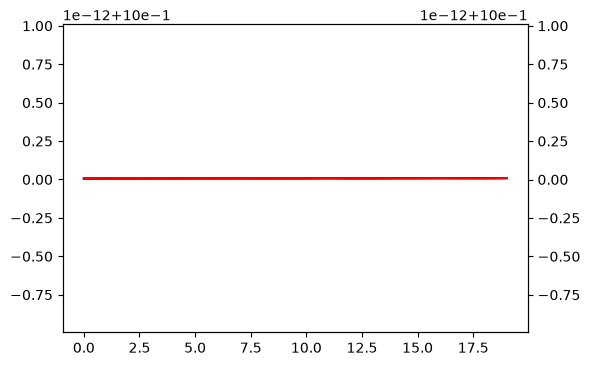

In [104]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [105]:
np.max(np.abs(np.array([l[4] for l in purification_rho_sweep_results])))

np.float64(5.46586661785669e-30)

#### Non-trivial

In [107]:
purification_rho_sweep_results = [l[1] for l in sweep_results[1]]

In [108]:
purification_rho_sweep_results[0][0]

array([0.23073156, 0.09532028, 0.01227544, 0.00512875])

In [109]:
purification_rho_sweep_results[-1][0]

array([2.49751040e-01, 9.81743714e-03, 5.28920800e-03, 2.45493418e-04])

In [110]:
schmidt_vals = [
    [x for x in l[0] if x > 0.005]
    for l in purification_rho_sweep_results
]

In [111]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [112]:
Counter(num_schmidt_vals)

Counter({4: 11, 3: 8, 2: 1})

In [113]:
purification_rho_sweep_results[0][0]

array([0.23073156, 0.09532028, 0.01227544, 0.00512875])

In [114]:
schmidt_vals

[[np.float64(0.23073156236934356),
  np.float64(0.09532027867512616),
  np.float64(0.01227544199255067),
  np.float64(0.005128754603844007)],
 [np.float64(0.2332837464339126),
  np.float64(0.08778962947096024),
  np.float64(0.017804936149599052),
  np.float64(0.007393162775100037)],
 [np.float64(0.2373537989794515),
  np.float64(0.07770231190901161),
  np.float64(0.009971282739998701),
  np.float64(0.005108654865678531)],
 [np.float64(0.24086354992599796),
  np.float64(0.06507351421832072),
  np.float64(0.015030735920479309)],
 [np.float64(0.2486314818433547),
  np.float64(0.023856252787661434),
  np.float64(0.010494976945818895)],
 [np.float64(0.24846214034869948),
  np.float64(0.025785065420230402),
  np.float64(0.009427912403320532)],
 [np.float64(0.21887761381315596), np.float64(0.1207481125845129)],
 [np.float64(0.2387638225307402),
  np.float64(0.07229420370117791),
  np.float64(0.015429175642984455),
  np.float64(0.005227399037820883)],
 [np.float64(0.24266190755968833),
  np.fl

In [115]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [117]:
pd.Series(schmidt_val_ratios).describe()

count    20.000000
mean      0.279927
std       0.127158
min       0.039309
25%       0.223122
50%       0.275625
75%       0.334866
max       0.551670
dtype: float64

Mostly unentangled. Seems valid.

In [118]:
left_defect_op_invariants = np.array([
    l[1] for l in purification_rho_sweep_results
])

right_defect_op_invariants = np.array([
    l[2] for l in purification_rho_sweep_results
])

In [119]:
(
    np.max(np.abs(np.imag(left_defect_op_invariants))),
    np.max(np.abs(np.imag(right_defect_op_invariants)))
)

(np.float64(5.551115123125783e-17), np.float64(5.551115123125783e-17))

In [120]:
left_defect_op_invariants = np.real(left_defect_op_invariants)
right_defect_op_invariants = np.real(right_defect_op_invariants)

In [121]:
np.round(left_defect_op_invariants, 3)

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1.])

In [122]:
np.round(right_defect_op_invariants, 3)

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1.])

In [123]:
overlaps = np.array([
    l[3] for l in purification_rho_sweep_results
])

In [124]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [125]:
overlaps = np.real(overlaps[:, -1])

In [126]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.956580
std       0.032008
min       0.875510
25%       0.947126
50%       0.962252
75%       0.975175
max       0.999004
dtype: float64

In [127]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_defect_op_invariants),
        np.real(right_defect_op_invariants)
    ),
    axis=-1
)

In [128]:
defect_results = defect_results[defect_results[:, 0].argsort()]

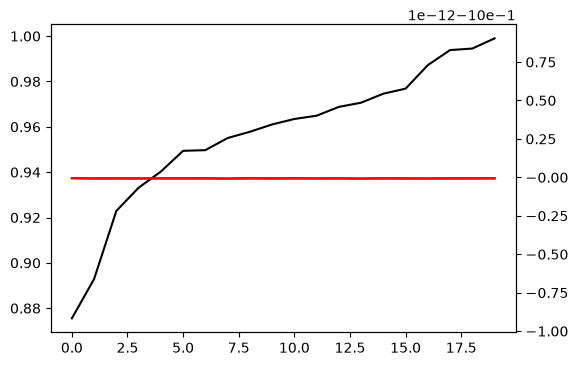

In [129]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

In [130]:
np.max(np.abs(np.array([l[4] for l in purification_rho_sweep_results])))

np.float64(1.6618902992047393e-30)

### Purificaiton and defect operators on cut states

#### Trivial

In [135]:
purification_diffs = [l[2] for l in sweep_results[0]]

In [136]:
np.max(np.abs(np.array(purification_diffs)))

np.float64(5.46586661785669e-30)

In [137]:
purification_cut_state_sweep_results = [l[3] for l in sweep_results[0]]

Each list contains:
1. Vertical singular value for that eigenvector
2. Left right singular values for resulting effective density matrix.
3. Left invariant
4. Right invariant
5. Overlaps

In [138]:
all_left_indices = [
    l1[2]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [139]:
all_right_indices = [
    l1[3]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [140]:
all_left_indices

[np.complex128(0.9999999999999998-1.3877787807814457e-17j),
 np.complex128(0.9999999999999999+0j),
 np.complex128(0.9999999999999999+0j),
 np.complex128(1.0000000000000002+5.551115123125783e-17j),
 np.complex128(1.0000000000000002-5.551115123125783e-17j),
 np.complex128(1.0000000000000002+0j),
 np.complex128(0.9999999999999998+5.551115123125783e-17j),
 np.complex128(1+5.551115123125783e-17j),
 np.complex128(1-5.551115123125783e-17j),
 np.complex128(1+5.551115123125783e-17j),
 np.complex128(1+0j),
 np.complex128(1.0000000000000004+9.71445146547012e-17j),
 np.complex128(1.0000000000000009+0j),
 np.complex128(0.9999999999999998+5.551115123125783e-17j),
 np.complex128(1.0000000000000004+5.551115123125783e-17j),
 np.complex128(0.9999999999999996+2.7755575615628914e-17j),
 np.complex128(1+5.551115123125783e-17j),
 np.complex128(0.9999999999999997-6.938893903907228e-17j),
 np.complex128(0.9999999999999996+0j),
 np.complex128(0.9999999999999998-5.551115123125783e-17j)]

In [141]:
all_right_indices

[np.complex128(0.9999999999999993-1.6653345369377348e-16j),
 np.complex128(0.9999999999999998+0j),
 np.complex128(1-2.0816681711721685e-17j),
 np.complex128(0.9999999999999996+0j),
 np.complex128(1.0000000000000004+2.0816681711721685e-17j),
 np.complex128(1+2.7755575615628914e-17j),
 np.complex128(1+7.112366251504909e-17j),
 np.complex128(1.0000000000000004-4.163336342344337e-17j),
 np.complex128(1.0000000000000002+6.938893903907228e-17j),
 np.complex128(1.0000000000000007+0j),
 np.complex128(0.9999999999999998+0j),
 np.complex128(1.0000000000000007-5.551115123125783e-17j),
 np.complex128(1.0000000000000002+0j),
 np.complex128(0.9999999999999998+1.3877787807814457e-17j),
 np.complex128(1.0000000000000004-1.1102230246251565e-16j),
 np.complex128(0.9999999999999991-5.551115123125783e-17j),
 np.complex128(0.9999999999999991-1.1102230246251565e-16j),
 np.complex128(0.9999999999999999+2.7755575615628914e-17j),
 np.complex128(1+0j),
 np.complex128(1+0j)]

In [142]:
all_overlaps = [
    l1[4][-1]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [143]:
all_overlaps

[np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999999),
 np.float64(1.0000000000000004),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000002),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000007),
 np.float64(1.0000000000000002),
 np.float64(1.0),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999997),
 np.float64(0.9999999999999998),
 np.float64(0.9999999999999998),
 np.float64(1.0000000000000002),
 np.float64(1.0)]

#### Non-trivial

In [144]:
purification_diffs = [l[2] for l in sweep_results[1]]

In [145]:
np.max(np.abs(np.array(purification_diffs)))

np.float64(1.6618902992047393e-30)

In [146]:
purification_cut_state_sweep_results = [l[3] for l in sweep_results[1]]

In [147]:
all_left_indices = [
    l1[2]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [148]:
all_right_indices = [
    l1[3]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [149]:
all_left_indices

[np.complex128(-1.0000000000000009+1.1102230246251565e-16j),
 np.complex128(-0.9999999999999996+0j),
 np.complex128(-1+0j),
 np.complex128(-1-1.1102230246251565e-16j),
 np.complex128(-0.9999999999999998-1.3877787807814457e-17j),
 np.complex128(-1.0000000000000002+5.551115123125783e-17j),
 np.complex128(-1+0j),
 np.complex128(-0.9999999999999997+0j),
 np.complex128(-1.0000000000000002+0j),
 np.complex128(-1-5.551115123125783e-17j),
 np.complex128(-0.9999999999999998+5.551115123125783e-17j),
 np.complex128(-1.0000000000000004+0j),
 np.complex128(-0.9999999999999998-5.551115123125783e-17j),
 np.complex128(-1-1.1102230246251565e-16j),
 np.complex128(-1+0j),
 np.complex128(-0.9999999999999999+5.551115123125783e-17j),
 np.complex128(-0.9999999999999998+8.326672684688674e-17j),
 np.complex128(-1.0000000000000002+0j),
 np.complex128(-1.0000000000000002+2.7755575615628914e-17j),
 np.complex128(-0.9999999999999998+0j),
 np.complex128(-0.9999999999999996+0j),
 np.complex128(-1.0000000000000002+0j

In [150]:
all_right_indices

[np.complex128(-1+0j),
 np.complex128(-0.9999999999999996+0j),
 np.complex128(-0.9999999999999987+0j),
 np.complex128(-0.9999999999999997+0j),
 np.complex128(-1.0000000000000004+0j),
 np.complex128(-1.0000000000000004-5.551115123125783e-17j),
 np.complex128(-1-5.551115123125783e-17j),
 np.complex128(-1-5.551115123125783e-17j),
 np.complex128(-0.9999999999999998+0j),
 np.complex128(-1+5.551115123125783e-17j),
 np.complex128(-1+0j),
 np.complex128(-1+0j),
 np.complex128(-0.9999999999999997-5.551115123125783e-17j),
 np.complex128(-0.9999999999999998+0j),
 np.complex128(-0.9999999999999996+0j),
 np.complex128(-0.9999999999999998+0j),
 np.complex128(-0.9999999999999991+1.1102230246251565e-16j),
 np.complex128(-1+2.7755575615628914e-17j),
 np.complex128(-0.9999999999999998+0j),
 np.complex128(-0.9999999999999993+5.551115123125783e-17j),
 np.complex128(-1.0000000000000004+5.551115123125783e-17j),
 np.complex128(-0.9999999999999997+0j),
 np.complex128(-0.9999999999999989+5.551115123125783e-17j

In [151]:
all_overlaps = [
    l1[4][-1]
    for l in purification_cut_state_sweep_results
    for l1 in l
]

In [152]:
all_overlaps

[np.float64(0.9999999999999998),
 np.float64(0.9999999999999996),
 np.float64(0.9999999999999992),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9999999999999999),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999999),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9999999999999999),
 np.float64(0.9999999999999996),
 np.float64(0.9999999999999999),
 np.float64(1.0),
 np.float64(0.9999999999999993),
 np.float64(1.0),
 np.float64(0.9999999999999998),
 np.float64(0.9999999999999994),
 np.float64(1.0),
 np.float64(0.9999999999999997),
 np.float64(0.9999999999999991),
 np.float64(0.9999999999999998),
 np.float64(1.0),
 np.float64(1.0000000000000004),
 np.float64(0.9999999999999997),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000004),
 np.float64(0.9999999999999998),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999997),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.9999999999999996),
 np.float64(0.99999999999

### Tensor network factorizations

#### Trivial

In [153]:
factorization_loss_curves = [l[4] for l in sweep_results[0]]

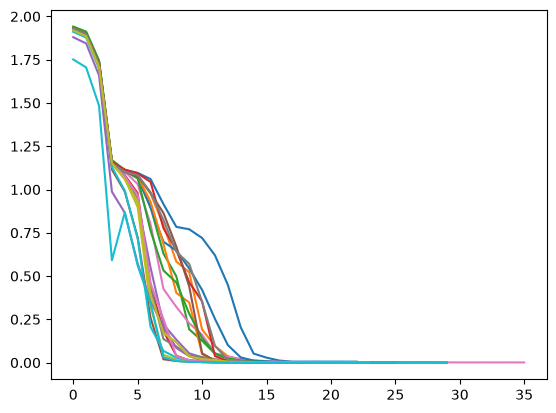

In [154]:
for l in factorization_loss_curves:
    plt.plot(l);

In [155]:
best_loss = [min(l) for l in factorization_loss_curves]

In [156]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.001061
std       0.001286
min       0.000153
25%       0.000313
50%       0.000656
75%       0.001239
max       0.005522
dtype: float64

In [157]:
left_loss = np.array([l[6] for l in sweep_results[0]])
right_loss = np.array([l[7] for l in sweep_results[0]])

In [158]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [159]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [160]:
np.max(left_loss), np.max(right_loss)

(np.float32(3.4571697e-12), np.float32(3.825843e-11))

#### Nontrivial

In [161]:
factorization_loss_curves = [l[4] for l in sweep_results[1]]

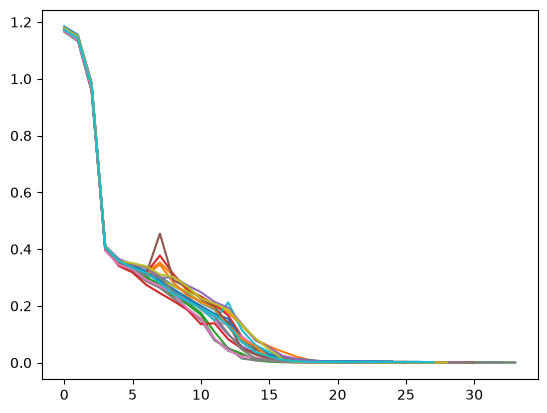

In [162]:
for l in factorization_loss_curves:
    plt.plot(l);

In [163]:
best_loss = [min(l) for l in factorization_loss_curves]

In [164]:
pd.Series(best_loss).describe()

count    20.000000
mean      0.001703
std       0.001316
min       0.000234
25%       0.000479
50%       0.001227
75%       0.002851
max       0.004551
dtype: float64

In [165]:
left_loss = np.array([l[6] for l in sweep_results[1]])
right_loss = np.array([l[7] for l in sweep_results[1]])

In [166]:
(
    np.max(np.abs(np.imag(left_loss))),
    np.max(np.abs(np.imag(right_loss)))
)

(np.float32(0.0), np.float32(0.0))

In [167]:
left_loss = np.real(left_loss)
right_loss = np.real(right_loss)

In [168]:
np.max(left_loss), np.max(right_loss)

(np.float32(4.5511663e-12), np.float32(3.4067712e-12))

### Factorized full effective density matrix

#### Trivial

In [169]:
schmidt_vals = [
    [x for x in l[8] if x > 0.05]
    for l in sweep_results[0]
]

In [170]:
schmidt_vals

[[np.float64(0.9433712183694514)],
 [np.float64(0.9649931210364349)],
 [np.float64(0.968967577912464)],
 [np.float64(0.979367576193457)],
 [np.float64(0.9778893451267795)],
 [np.float64(0.9888305759385732)],
 [np.float64(0.9648005164827185)],
 [np.float64(0.9804587963324415)],
 [np.float64(0.9732437489206403)],
 [np.float64(0.987517260776019)],
 [np.float64(0.9551214012990109)],
 [np.float64(0.9765572139650444)],
 [np.float64(0.9749288813315133)],
 [np.float64(0.9818984648558475)],
 [np.float64(0.9851620323232617)],
 [np.float64(0.9858426640922497)],
 [np.float64(0.9865084965791658)],
 [np.float64(0.986090123523429)],
 [np.float64(0.9697125240635743)],
 [np.float64(0.9901760287702206)]]

In [171]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [172]:
Counter(num_schmidt_vals)

Counter({1: 20})

In [173]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [174]:
pd.Series(schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

In [175]:
left_invariants = [l[9] for l in sweep_results[0]]
right_invariants = [l[10] for l in sweep_results[0]]

In [176]:
left_invariants

[np.complex128(1.0000000000000075-2.9000027379488813e-10j),
 np.complex128(1.0000000000000067-3.487043986893923e-12j),
 np.complex128(1.0000000000000044-3.584277319390594e-11j),
 np.complex128(1.000000000000001-1.226881929383694e-10j),
 np.complex128(1.0000000000000044+9.655415356135677e-12j),
 np.complex128(1.000000000000006+1.0787243320820039e-10j),
 np.complex128(0.9999999999999873+2.0744451989518353e-10j),
 np.complex128(1.0000000000000018+5.657607715647828e-11j),
 np.complex128(1.000000000000007-1.2149214967394073e-10j),
 np.complex128(1.0000000000000053+1.0643513848052066e-11j),
 np.complex128(1.0000000000000036-3.1917302134587544e-11j),
 np.complex128(1.0000000000000047+1.0298339958580982e-10j),
 np.complex128(1.0000000000000049-4.359013150434521e-11j),
 np.complex128(1.0000000000000075+2.1252541393401714e-11j),
 np.complex128(1.0000000000000058-4.7494341792742034e-11j),
 np.complex128(1.0000000000000044+9.719043625455726e-11j),
 np.complex128(1.0000000000000022-4.46139514220789

In [177]:
right_invariants

[np.complex128(1.0000000000000069+4.702421785296451e-10j),
 np.complex128(1.0000000000000062+3.7065475688713434e-11j),
 np.complex128(1.0000000000000033+1.6993866036596472e-10j),
 np.complex128(1.0000000000000064-1.0054235222156649e-11j),
 np.complex128(1.0000000000000058+6.330624913175598e-11j),
 np.complex128(1.0000000000000069-2.0551560453441198e-11j),
 np.complex128(0.9999999999999982-1.4167982759216713e-09j),
 np.complex128(1.0000000000000064-2.347316785389353e-11j),
 np.complex128(0.9999999999999925-3.7051911538910076e-10j),
 np.complex128(1.000000000000007+3.15261705630121e-11j),
 np.complex128(1.0000000000000053+7.737137319718812e-11j),
 np.complex128(1.0000000000000064-7.404368784769133e-12j),
 np.complex128(1.0000000000000049+9.59967522140559e-12j),
 np.complex128(0.9999999999999918+1.2974799012965832e-10j),
 np.complex128(1.0000000000000009+1.3936796161573284e-11j),
 np.complex128(1.000000000000005+1.1474335370742494e-11j),
 np.complex128(1.0000000000000067+6.048749001674736

In [178]:
overlaps = np.array([l[11][-1] for l in sweep_results[0]])

In [179]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [180]:
overlaps = np.real(overlaps)

In [181]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.986476
std       0.006628
min       0.973404
25%       0.982694
50%       0.988318
75%       0.991695
max       0.996202
dtype: float64

In [182]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [183]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

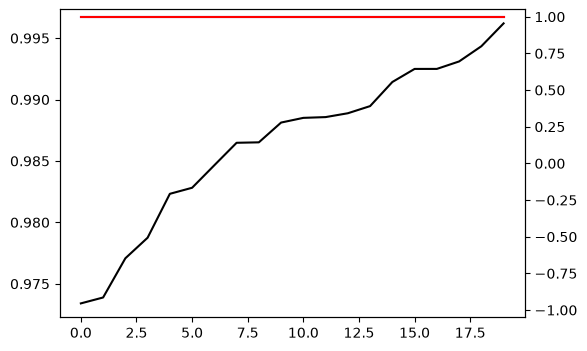

In [184]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

#### Nontrivial

In [185]:
schmidt_vals = [
    [x for x in l[8] if x > 0.005]
    for l in sweep_results[1]
]

In [186]:
schmidt_vals

[[np.float64(0.229768149934082)],
 [np.float64(0.22740744138983168)],
 [np.float64(0.2428406970152252)],
 [np.float64(0.23947499893037527)],
 [np.float64(0.24269111732103746)],
 [np.float64(0.238788859978702)],
 [np.float64(0.23390224935438084)],
 [np.float64(0.23136406533878742)],
 [np.float64(0.23192385599743137)],
 [np.float64(0.22607921825679106)],
 [np.float64(0.22736448019182548)],
 [np.float64(0.2362986946627049)],
 [np.float64(0.24180278129545935)],
 [np.float64(0.23786538947742464)],
 [np.float64(0.2305076748796364)],
 [np.float64(0.23791916461086468)],
 [np.float64(0.24170334452499836)],
 [np.float64(0.24439186971518156)],
 [np.float64(0.24192600897638572)],
 [np.float64(0.23295521378649992)]]

In [187]:
num_schmidt_vals = [len(l) for l in schmidt_vals]

In [188]:
Counter(num_schmidt_vals)

Counter({1: 20})

In [189]:
schmidt_val_ratios = [
    get_schmidt_vals_ratio(l)
    for l in schmidt_vals
]

In [190]:
pd.Series(schmidt_val_ratios).describe()

count    20.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64

In [191]:
left_invariants = [l[9] for l in sweep_results[1]]
right_invariants = [l[10] for l in sweep_results[1]]

In [192]:
left_invariants

[np.complex128(-0.9999999999999925+0j),
 np.complex128(-0.9999999999999915+0j),
 np.complex128(-1.0000000000000009-5.551115123125783e-17j),
 np.complex128(-1.0000000000000029+2.7755575615628914e-17j),
 np.complex128(-0.9999999999999998+5.551115123125783e-17j),
 np.complex128(-1.0000000000000053+8.673617379884035e-19j),
 np.complex128(-1.0000000000000009+0j),
 np.complex128(-1.0000000000000018+1.3877787807814457e-17j),
 np.complex128(-0.9999999999999872-2.7755575615628914e-17j),
 np.complex128(-0.9999999999999933-2.7755575615628914e-17j),
 np.complex128(-0.9999999999999923-6.938893903907228e-18j),
 np.complex128(-1.0000000000000002+5.551115123125783e-17j),
 np.complex128(-1.0000000000000029-1.3877787807814457e-17j),
 np.complex128(-0.9999999999999988-1.3877787807814457e-17j),
 np.complex128(-0.9999999999999978+2.7755575615628914e-17j),
 np.complex128(-1.0000000000000016+0j),
 np.complex128(-0.9999999999999972+0j),
 np.complex128(-1.0000000000000038+2.7755575615628914e-17j),
 np.complex1

In [193]:
right_invariants

[np.complex128(-0.9999999999999932-2.7755575615628914e-17j),
 np.complex128(-0.9999999999999986+0j),
 np.complex128(-1.0000000000000056-2.7755575615628914e-17j),
 np.complex128(-0.9999999999999922+0j),
 np.complex128(-0.9999999999999821+0j),
 np.complex128(-1.0000000000000053+0j),
 np.complex128(-0.9999999999999984+5.551115123125783e-17j),
 np.complex128(-1.0000000000000013-5.551115123125783e-17j),
 np.complex128(-0.9999999999999961+0j),
 np.complex128(-1.0000000000000027+0j),
 np.complex128(-1.000000000000004+3.469446951953614e-18j),
 np.complex128(-0.9999999999999963+0j),
 np.complex128(-1.0000000000000004+0j),
 np.complex128(-0.9999999999999988-5.551115123125783e-17j),
 np.complex128(-1.0000000000000027+2.7755575615628914e-17j),
 np.complex128(-0.9999999999999967+2.7755575615628914e-17j),
 np.complex128(-1.000000000000003+4.163336342344337e-17j),
 np.complex128(-0.9999999999999987+2.7755575615628914e-17j),
 np.complex128(-1.000000000000003+0j),
 np.complex128(-1.000000000000001+2.77

In [194]:
overlaps = np.array([l[11][-1] for l in sweep_results[1]])

In [195]:
np.max(np.abs(np.imag(overlaps)))

np.float64(0.0)

In [196]:
overlaps = np.real(overlaps)

In [197]:
pd.Series(overlaps).describe()

count    20.000000
mean      0.943318
std       0.023588
min       0.904136
25%       0.924478
50%       0.948277
75%       0.966884
max       0.977556
dtype: float64

In [198]:
defect_results = np.stack(
    (
        overlaps,
        np.real(left_invariants),
        np.real(right_invariants)
    ),
    axis=-1
)

In [199]:
defect_results = defect_results[defect_results[:, 0].argsort()]

(-1.05, 1.05)

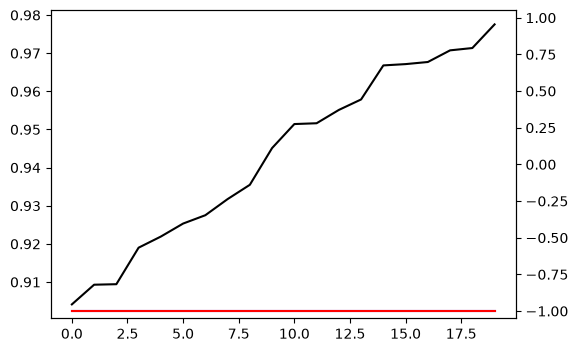

In [200]:
fig, ax1 = plt.subplots(figsize=(6, 4))

ax1.plot(defect_results[:, 0], color='k')
ax2 = ax1.twinx()

ax2.plot(defect_results[:, 1], color='b')
ax2.plot(defect_results[:, 2], color='r')

ax2.set_ylim(-1.05, 1.05)

### Factorized cut states

#### Trivial

In [201]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results[0]]

In [202]:
factorized_cut_state_sweep_results[0][0]

[np.float32(1.1225727),
 np.float32(0.8627993),
 array([9.99696328e-01, 5.52016730e-04, 5.44294678e-04, 1.66074095e-04,
        1.65730289e-04, 5.70028036e-06, 5.44460249e-06, 1.94718095e-06,
        6.49000065e-07, 3.42757149e-07, 1.52550777e-07, 5.46549417e-08,
        3.10225867e-08, 1.97927472e-08, 9.15877364e-09, 4.56783493e-09]),
 np.complex128(0.9999999850988388-1.1102230246251565e-16j),
 np.complex128(0.9999999981373557+3.731111064553261e-08j),
 np.float64(0.999946946486664)]

In [203]:
all_left_indices = [
    l1[4]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [204]:
all_left_indices

[np.complex128(0.9999999981373557+3.731111064553261e-08j),
 np.complex128(0.9999997906852507-7.479684427380562e-09j),
 np.complex128(0.9999997615814212+7.450580735701706e-09j),
 np.complex128(1.0000003427267075-2.793967612824133e-09j),
 np.complex128(0.999999687075615-2.066371809772427e-09j),
 np.complex128(1.0000001043081188+8.14890266376267e-09j),
 np.complex128(1.0000002831220627-6.984919254104938e-09j),
 np.complex128(1.0000000754371285-7.334165275096893e-09j),
 np.complex128(1.000000044703484-9.313225711460316e-09j),
 np.complex128(1.000000029802323+6.286427434165631e-09j),
 np.complex128(1.000000149011612+2.444721897143509e-09j),
 np.complex128(0.9999999180436133-1.1641532182693481e-08j),
 np.complex128(0.9999999701976776-7.450580513657101e-09j),
 np.complex128(1.0000000894069674-1.8626452602532595e-09j),
 np.complex128(1.0000001788139343-1.1175870895385742e-08j),
 np.complex128(0.9999997764825828-2.235174181852706e-08j),
 np.complex128(0.9999999441206454-1.4551914950811096e-09j)

In [205]:
all_right_indices = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [206]:
all_right_indices

[np.float64(0.999946946486664),
 np.float64(0.9999645647650897),
 np.float64(0.999908173869525),
 np.float64(0.9999968527596247),
 np.float64(0.9999780766206373),
 np.float64(0.9999966082558693),
 np.float64(0.999980147556204),
 np.float64(0.9999950829846225),
 np.float64(0.9999925016282815),
 np.float64(0.9999756842601419),
 np.float64(0.9997913693899421),
 np.float64(0.9999483523619139),
 np.float64(0.9999079288256321),
 np.float64(0.9999562760367255),
 np.float64(0.9999915257689493),
 np.float64(0.9999351892362118),
 np.float64(0.9999976178528359),
 np.float64(0.9999929343839508),
 np.float64(0.9999881734223617),
 np.float64(0.9999952282039681)]

In [213]:
all_overlaps = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [214]:
all_overlaps

[np.float64(0.9988017155493799),
 np.float64(0.9993830455415093),
 np.float64(0.9984946605191002),
 np.float64(0.999497185495223),
 np.float64(0.999119954070472),
 np.float64(0.9981952536990192),
 np.float64(0.9985503589762003),
 np.float64(0.9990499910126796),
 np.float64(0.9998928385759811),
 np.float64(0.9998645067370018),
 np.float64(0.9998729576783769),
 np.float64(0.9998074280102173),
 np.float64(0.9995469531758197),
 np.float64(0.9997515962288696),
 np.float64(0.999743169590626),
 np.float64(0.9998418174495366),
 np.float64(0.9999116102032891),
 np.float64(0.9998900092310445),
 np.float64(0.9998650316354205),
 np.float64(0.9998621923326699),
 np.float64(0.9980646092116204),
 np.float64(0.9995668532522195),
 np.float64(0.9991530902555085),
 np.float64(0.9996721714927691),
 np.float64(0.9987351665461062),
 np.float64(0.9992707536779939),
 np.float64(0.9991839429785824),
 np.float64(0.9991533251526612),
 np.float64(0.9946133628268683),
 np.float64(0.996693771699502),
 np.float64(0.

#### Nontrivial

In [215]:
factorized_cut_state_sweep_results = [l[12] for l in sweep_results[1]]

In [216]:
factorized_cut_state_sweep_results[0][0]

[np.float32(0.6306787),
 np.float32(0.8312371),
 array([4.99290065e-01, 1.40956046e-03, 5.91623326e-04, 5.18816171e-04,
        2.70961854e-04, 2.17695145e-04, 1.44688805e-04, 1.14336151e-04,
        7.21470463e-05, 3.56707053e-05, 3.55098640e-05, 4.28445843e-06,
        1.82727307e-06, 3.12068142e-07, 2.35657594e-07, 1.25918712e-07]),
 np.complex128(-0.9999999701976785+1.1102230246251565e-16j),
 np.complex128(-0.9999999254941937+5.58793539218172e-09j),
 np.float64(0.9988017155493799)]

In [221]:
all_left_indices = [
    l1[3]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [222]:
all_left_indices

[np.complex128(-0.9999999701976785+1.1102230246251565e-16j),
 np.complex128(-0.9999999254941945+1.1102230246251565e-16j),
 np.complex128(-1.000000163912773-1.1102230246251565e-16j),
 np.complex128(-0.9999998509883878+0j),
 np.complex128(-1.000000044703484-5.551115123125783e-17j),
 np.complex128(-0.9999998658895496-1.3877787807814457e-17j),
 np.complex128(-0.9980043966741846+7.885210041969071e-05j),
 np.complex128(-0.9996164422917572-0.0001507797446714254j),
 np.complex128(-0.9999999403953556+4.440892098500626e-16j),
 np.complex128(-0.999999940395355+2.682853939006691e-13j),
 np.complex128(-0.9999051730338717+7.3888969147617445e-06j),
 np.complex128(-0.9998453692129298-2.479088971607535e-06j),
 np.complex128(-0.9998594320050416+1.5162647972799537e-05j),
 np.complex128(-1.0000000447034836+0j),
 np.complex128(-1.000000193714924-1.8198194617902175e-09j),
 np.complex128(-1.0000000894069678+0j),
 np.complex128(-0.99999988079071+2.886579864025407e-15j),
 np.complex128(-0.9999997427306353+3.29

In [223]:
all_right_indices = [
    l1[4]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [224]:
all_right_indices

[np.complex128(-0.9999999254941937+5.58793539218172e-09j),
 np.complex128(-0.9999999776482582-2.793967728009772e-08j),
 np.complex128(-1.0000001192092889-1.1175870895385742e-08j),
 np.complex128(-0.9999999180436128+1.816079009397953e-08j),
 np.complex128(-1.0000000670552254+1.7695128948919114e-08j),
 np.complex128(-0.9999998062849047-4.6566130951219975e-09j),
 np.complex128(-0.9989764765564793+5.3468327162853324e-05j),
 np.complex128(-0.9995173040814367-3.7914760069091e-05j),
 np.complex128(-0.9999998584389683+3.7252906315288215e-09j),
 np.complex128(-0.9999999813735482-6.14673698051682e-08j),
 np.complex128(-0.9998614819719488+3.421630685368493e-06j),
 np.complex128(-0.9998636562197298-5.382271865361776e-06j),
 np.complex128(-0.9996756347817406-4.441611871908169e-05j),
 np.complex128(-1.0000000139698388-1.816079020500183e-08j),
 np.complex128(-1.000000083818644+1.0102717440396702e-08j),
 np.complex128(-1.0000002244487405+1.1408701539039612e-08j),
 np.complex128(-0.9999999403953552+4.6

In [225]:
all_overlaps = [
    l1[5]
    for l in factorized_cut_state_sweep_results
    for l1 in l
]

In [226]:
all_overlaps

[np.float64(0.9988017155493799),
 np.float64(0.9993830455415093),
 np.float64(0.9984946605191002),
 np.float64(0.999497185495223),
 np.float64(0.999119954070472),
 np.float64(0.9981952536990192),
 np.float64(0.9985503589762003),
 np.float64(0.9990499910126796),
 np.float64(0.9998928385759811),
 np.float64(0.9998645067370018),
 np.float64(0.9998729576783769),
 np.float64(0.9998074280102173),
 np.float64(0.9995469531758197),
 np.float64(0.9997515962288696),
 np.float64(0.999743169590626),
 np.float64(0.9998418174495366),
 np.float64(0.9999116102032891),
 np.float64(0.9998900092310445),
 np.float64(0.9998650316354205),
 np.float64(0.9998621923326699),
 np.float64(0.9980646092116204),
 np.float64(0.9995668532522195),
 np.float64(0.9991530902555085),
 np.float64(0.9996721714927691),
 np.float64(0.9987351665461062),
 np.float64(0.9992707536779939),
 np.float64(0.9991839429785824),
 np.float64(0.9991533251526612),
 np.float64(0.9946133628268683),
 np.float64(0.996693771699502),
 np.float64(0.

# Conclusions
All looks good.

# Old code

## Test random unitaries

In [56]:
fixed_psi = quimb_fixed_point_groundstates[0]

In [57]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(fixed_psi)

In [58]:
fixed_psi.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

In [59]:
rand_psi.shape

(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)

In [63]:
qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b']
)

In [64]:
qu_X_sym_gates = qtn.TensorNetwork(
    [qu_X.reindex({'k': f'k{i}', 'b': f'b{i}'}) for i in range(num_sites)],
    virtual=True
)

In [65]:
sym_fixed_psi = (
    fixed_psi.conj().reindex({f'k{i}': f'b{i}' for i in range(num_sites)})
    & qu_X_sym_gates
)

sym_fixed_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

In [60]:
(fixed_psi.conj() & fixed_psi).contract()

np.complex128(1+0j)

In [61]:
(rand_psi.conj() & rand_psi).contract()

np.complex128(1.0000000000000073+0j)

In [62]:
np.abs((rand_psi.conj() & fixed_psi).contract())

np.float64(1.012192758097372e-05)

In [67]:
np.abs((sym_fixed_psi.conj() & sym_fixed_psi).contract())

np.float64(1.0000000000000009)

In [68]:
np.abs((fixed_psi.conj() & sym_fixed_psi).contract())

np.float64(0.9999999999999987)

In [69]:
sym_rand_psi = (
    rand_psi.conj().reindex({f'k{i}': f'b{i}' for i in range(num_sites)})
    & qu_X_sym_gates
)

sym_rand_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

In [70]:
(sym_rand_psi.conj() & sym_rand_psi).contract()

np.complex128(1.000000000000007+0j)

In [71]:
np.abs((rand_psi.conj() & sym_rand_psi).contract())

np.float64(1.0000000000000069)